<a href="https://colab.research.google.com/github/raju1207/fake-news-detection/blob/main/fake_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Libraries**

In [24]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from datasets import Dataset


In [26]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import torch

**Load Dataset**

In [27]:
News_data = pd.read_csv("news.csv")

In [28]:
News_data.head()

,text,label
0,Gere faults Trump for blurring meaning of 'ref...,1
1,German parties start to find common ground in ...,1
2,Senate Democratic leader says Attorney General...,1
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",1
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,0


In [29]:
News_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45757 entries, 0 to 45756
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    45757 non-null  object
 1   label   45757 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 715.1+ KB


In [30]:
News_data.shape

(45757, 2)

In [31]:
News_data.columns

Index(['text', 'label'], dtype='object')

**Exploratory Data Analysis (EDA)**

In [32]:
News_data["label"].value_counts()

,count
label,
1,22900
0,22857


<Axes: xlabel='label'>

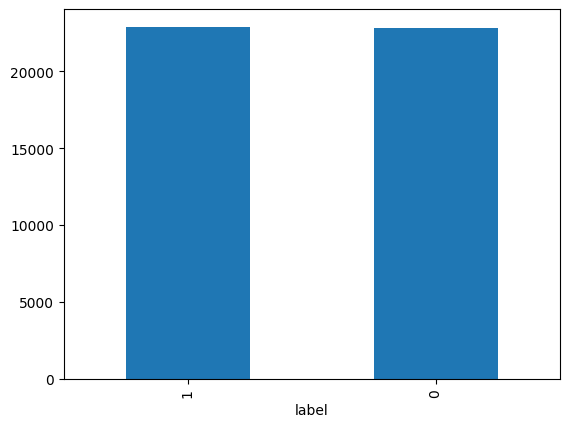

In [33]:
News_data["label"].value_counts().plot(kind="bar")

In [34]:
News_data.sample(5)

,text,label
30259,POLL: Bristol Palin Wants To Know Whose Voice...,0
39555,Mattis says U.S. effort on North Korea aims fo...,1
43444,Prize for Winning Frat Bros Game of Rock Paper...,0
32300,Chinese media upbeat on U.S. ties ahead of Tru...,1
20761,Women's Rugby League World Cup: England name 1...,1


**Data Preprocessing**

In [35]:
#Check Missing Values

News_data.isnull().sum()

,0
text,0
label,0


In [36]:
#Remove Duplicates

News_data.duplicated().sum()

np.int64(0)

In [37]:
News_data.drop_duplicates(inplace=True)